# SSW 2026 I Group Project: Single Point Lens Microlensing

Casey Lam (Carnegie), Ali Crisp (OSU), Scott Gaudi (OSU), Katarzyna Kruszynska (LCO), Amber Malpas (OSU),  Arjun Mulidhar (OSU), Himanshu Verma(LSU)

Prior to running this notebook, be sure to run the setup notebook:  SSW2026_HandsOnI_Microlens_Setup.ipynb. The setup notebook just needs to be run **once**.

## Google Colab Usage

**Confirm login account**
* Please make sure to be logged in with the Google account you want to use for the exercises before running the code cells below. You can check by clicking the circular account icon in the top right corner of the colab notebook.

**Google Drive directory**
* Note: data will be copied in a directory called "SSW2026/Microlens" in your Google drive by the Setup notebook.

**Running cells**
* Run cells individually by clicking on the triangle on each cell
* For text cells, you can click the down arrow to get to the next cell

**To Restart runtime**
*   Click on Runtime menu item
*   Select Restart session
*   Select Run code cells individually from the top

**To Recreate runtime**
*   Click on Runtime menu item
*   Select Disconnect and Delete runtime
*   Select Run code cells individually from the top

**To Exit:**
*   Close the browser window

# `Sagan 2026 Group Project:` Single Point Lens Microlensing
`Objective:`
1. **Load and visualize** a simulated Roman-like microlensing light curve.
2. **Rough estimate of initial parameters** using the light curve data.
3. Fit a **PSPL** (Point Source Point Lens) model (Minimizer). Obtain best fit model and report parameters with minimum $\chi^2$, degree of freedom (dof), and z-score.
4. Run **MCMC for PSPL**: Visualize chains, posterior corner plots, and fitted light curve. Report parameters and their respective errors with minimum $\chi^2$, degree of freedom (dof), and z-score.
5. Test a higher-order effect model — **Finite-Source, Parallax, or Both** (Minimizer). *Requires data reduction.*
6. **Compare** the higher-order effect models with PSPL using their minimum $\chi^2$, $\chi^2$/dof, and z-score.
7. OPTIONAL: Run MCMC for the higher-order model

**This notebook is completed as a working answer key.** Set `group_number` to your assigned file (1–240), then run all cells after the restart. Higher-order default is **FSPL**; switch to parallax options in Section 5 if desired.

If you are doing **Project-2 (Binary Lens)**, use `SSW2026_HandsOnI_Binary_Lens.ipynb` with an event from the Binary-Events data set instead.


---
## Quick-review: Microlensing Parameters & MulensModel
Before we begin, let's review the core parameters of a microlensing event and typical values for a Galactic bulge event:

**PSPL model Parameters:**
* **$t_0$**: Time of closest approach (peak magnification).
* **$u_0$**: Impact parameter (minimum distance between lens and source, normalized by the Einstein angle $\theta_E$). *Typical range: ~0 (high mag) to 1.0 (low mag).*
* **$t_E$**: Einstein ring crossing time. *Typical range: ~a few days to 100+ days.*
* **$fs$**: The source flux fraction ($f_s$) is simply the ratio of the magnifiable light from the lensing star to the total observed baseline light ($f_s = F_s / [F_s + F_b]$), which might contain unrelated blending from other stars in the crowded field. *Typical range: 0-1.*

Note: The Einstein angle is a related to the lens mass ($M_L$) and the distances to both the lens ($D_L$) and the source($D_S$), expressed as $\theta_E = \sqrt{\frac{4 G M_L}{c^2}\left(\frac{1}{D_L} - \frac{1}{D_S}\right)}$. The Einstein crossing time as $t_E=\frac{\theta_E}{\mu_\textrm{rel}}$, where $\mu_\textrm{rel}$ is the relative proper motion between the lens and the source.

**Higher-Order model additional Parameters:**
* **$\rho$ (FSPL)**: Normalized source radius ($\theta_* / \theta_E$). Finite source effects manifest strongly when the lens transits the source ($u_0 \lesssim \rho$). *Typical range: $10^{-3}$ to $1$.*
* **$\pi_{E,N}, \pi_{E,E}$ (Parallax)**: North and East components of the microlens parallax vector, normalized by the Einstein angle. This accounts for the Earth's orbital motion deviating from a straight line during the event. *Typical range: -1 to 1*
* fixed parameters--**t_0_ref, ra, dec**: Reference time, R.A. and Dec. for parallax (remain fixed)


**MulensModel Core Modules:**
Throughout this notebook, you will use three main classes from the `MulensModel` framework:
1.  `mm.MulensData`: object holds discrete lightcurve data: time, magnitude or flux, and its uncertainty (in that order). Full documentation at https://rpoleski.github.io/MulensModel/MulensModel.mulensdata.html#module-MulensModel.mulensdata
2.  `mm.Model`: defines a microlensing model and stores the physical parameters and computes the theoretical magnification $A(t)$. Full documentation is at https://rpoleski.github.io/MulensModel/MulensModel.model.html#module-MulensModel.model
3.  `mm.Event`: object takes a `Model` object and a `MulensData` object and links them together. This is useful because it enables the calculation of the $\chi^2$ goodness of fit statistic.Full documentation is at https://rpoleski.github.io/MulensModel/MulensModel.event.html#module-MulensModel.event . We can instantiate an `Event` object using the `Model` and `MulensData` objects created.

In [1]:
# Install software (Colab or local)
%pip install --quiet MulensModel emcee corner iminuit

# Colab widget bug work-around (safe to ignore outside Colab)
try:
    get_ipython().kernel.do_shutdown(restart=True)
except Exception as exc:
    print('Skip kernel restart outside Colab:', type(exc).__name__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.2/448.2 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.6 MB/s eta 0:00:00


###❗ **Restart session** ❗
You may need to restart the session - this was likely already done - you may have seen a runtime has crashed message which was the auto restart. If not, you can do a manual restart  (dropdown menu next to "Run all" button) After you restart the session, don't re-run the above cells, just continue with the next cell.

In [1]:
# COLAB-ONLY custom widgets
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    print('Not on Google Colab — skipping custom widget manager.')


In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import MulensModel as mm
import pandas as pd
import emcee
import corner
from iminuit import minimize

In [3]:
# Mount Google Drive on Colab; skip when local data is available
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Not on Google Colab — using local/extracted pointlensdata if available.')


Mounted at /content/drive


In [4]:
# Choose your assigned group-project number (1-240)
# Change this to your assigned file number, e.g. 15 -> GrpProjData15.csv
group_number = 1  #@param {type:"integer"}

ssw_dir = 'SSW2026/Microlens' #@param {type:"string"}


In [5]:
# Define directory
import os
import sys

# Prefer local extracted workshop data if present; otherwise use Google Drive (Colab)
local_pointlens = os.path.abspath(os.path.join(os.getcwd(), 'data', 'pointlensdata'))
alt_local_pointlens = os.path.abspath(os.path.join(os.getcwd(), 'Assignments Notebooks', 'data', 'pointlensdata'))

if os.path.isdir(local_pointlens):
    pointlensdata_path = local_pointlens
elif os.path.isdir(alt_local_pointlens):
    pointlensdata_path = alt_local_pointlens
else:
    # Google top level drive dir (Colab)
    drive_dir = "/content/drive/MyDrive/"
    ssw_path = os.path.join(drive_dir, ssw_dir)
    pointlensdata_path = os.path.join(ssw_path, 'pointlensdata')

print('Using pointlensdata_path =', pointlensdata_path)
assert os.path.isdir(pointlensdata_path), (
    'pointlensdata folder not found. Run the Setup notebook or extract microlens_data.tar.gz.'
)


Using pointlensdata_path = /content/drive/MyDrive/SSW2026/Microlens/pointlensdata


## Helper Functions
*(Provided for you - run this cell to initialize)*

In [6]:
def chi2_fun(theta, parameters_to_fit, event):
    """
    Calculate chi2 for given values of parameters.

    Keywords :
        theta: *np.ndarray*
            Vector of parameter values, e.g.,
            `np.array([5380., 0.5, 20.])`.

        parameters_to_fit: *list* of *str*
            List of names of parameters corresponding to theta, e.g.,
            `['t_0', 'u_0', 't_E']`.

        event: *MulensModel.Event*
            Event which has datasets for which chi2 will be calculated.

    Returns :
        chi2: *float*
            Chi2 value for given model parameters.
    """
    # First we have to change the values of parameters in
    # event.model.parameters to values given by theta.
    for (parameter, value) in zip(parameters_to_fit, theta):
        setattr(event.model.parameters, parameter, value)
    event.fit_fluxes()  # Fit source and blend fluxes to the data
    # After that, calculating chi2 is trivial:
    return event.get_chi2()

def ln_like(theta, event, parameters_to_fit):
    """
    Calculate the log-likelihood. For a Gaussian log-likelihood function, this
    is equal to -0.5 * chi2.
    """
    for (parameter, value) in zip(parameters_to_fit, theta):
        setattr(event.model.parameters, parameter, value)
    chi2 = event.get_chi2()
    if chi2 < ln_like.best[0]:
        # Functions can have attributes. We have an attribute called "best",
        # which contains the smallest chi2 and the corresponding parameters.
        ln_like.best = [chi2, theta]
    return -0.5 * chi2

# Create the "best" attribute.
ln_like.best = [np.inf]

def ln_prior(theta, parameters_to_fit, event):
    """
    Calculate the log-prior.
    t_E and rho are not allowed to be negative,
    and we have a condition that disfavors negative blending (fs > 1).
    """
    if theta[parameters_to_fit.index('t_E')] < 0.: return -np.inf
    d = dict(zip(parameters_to_fit, theta))
    if 'rho' in d and d['rho'] < 1e-6: return -np.inf

    for (parameter, value) in zip(parameters_to_fit, theta):
        setattr(event.model.parameters, parameter, value)
    event.fit_fluxes()
    source_flux = event.source_fluxes[0]
    blend_flux = event.blend_fluxes[0]
    fs = source_flux/(source_flux + blend_flux)

    if fs > 1:
         mean = 1.
         sigma = 0.1
         return -0.5 * ((fs - mean) / sigma)**2
    return 0.0

def ln_prob(theta, event, parameters_to_fit):
    """
    Calculate the log-posterior. Since the product of the prior and the likelihood
    is proportional to the posterior, the sum of the log-prior and the
    log-likelihood is proportional to the log-posterior
    """
    ln_prior_ = ln_prior(theta, parameters_to_fit, event)
    event.fit_fluxes()
    source_flux = event.source_fluxes[0]
    blend_flux = event.blend_fluxes[0]
    fs = source_flux/(source_flux + blend_flux)

    if not np.isfinite(ln_prior_): return (-np.inf, fs)
    ln_like_ = ln_like(theta, event, parameters_to_fit)
    if np.isnan(ln_like_): return (-np.inf, fs)

    return (ln_prior_ + ln_like_, fs)

#------------ Data binning functions to speed up higher order effect exploration -----------------
def bin_lightcurve(data, bin_width_days):
    t, m, e = data['time'].values, data['magF146'].values, data['magF146err'].values
    bins = np.arange(t.min(), t.max() + bin_width_days, bin_width_days)
    bin_idx = np.digitize(t, bins)
    t_bin, m_bin, e_bin = [], [], []
    for i in range(1, len(bins)):
        mask = bin_idx == i
        if mask.sum() == 0: continue
        w = 1.0 / e[mask]**2
        t_bin.append(np.average(t[mask]))
        m_bin.append(np.average(m[mask], weights=w))
        e_bin.append(1.0 / np.sqrt(w.sum()))
    return pd.DataFrame({'time': t_bin, 'magF146': m_bin, 'magF146err': e_bin})

def reduce_data_to_speedup(data, bin_width_days, peak=None, t_range=None):
    if t_range is not None:
        t_min, t_max = t_range
        if t_min is not None: data = data[data['time'] >= t_min]
        if t_max is not None: data = data[data['time'] <= t_max]
        data = data.reset_index(drop=True)

    if peak is not None:
        t_peak, t_fwhm, peak_bin_width = peak
        near = (data['time'] >= t_peak - t_fwhm) & (data['time'] <= t_peak + t_fwhm)
        data_peak, data_outer = data[near], data[~near]
        if peak_bin_width and len(data_peak) > 0:
            data_peak = bin_lightcurve(data_peak, peak_bin_width)
    else:
        data_peak = pd.DataFrame(columns=data.columns)
        data_outer = data

    binned_outer = bin_lightcurve(data_outer, bin_width_days)
    return pd.concat([binned_outer, data_peak]).sort_values('time').reset_index(drop=True)

# Available finite source magnification methods for FSPL models
# Method index 1: finite_source_uniform_Gould94_direct  (1e-3 < rho < 1, recommended)
finite_source_methods = [
    'finite_source_uniform_Gould94',         # 0: 1e-3 < rho < 1 (has a bug)
    'finite_source_uniform_Gould94_direct',  # 1: 1e-3 < rho < 1  <-- recommended
    'finite_source_uniform_WittMao94',       # 2: rho < 0.01
    'finite_source_uniform_Lee09',           # 3: rho > 0.01
    'finite_source_LD_WittMao94',            # 4: rho < 0.01 (limb-darkened)
    'finite_source_LD_Yoo04',               # 5: 1e-3 < rho < 1  (limb-darkened)
    'finite_source_LD_Yoo04_direct',        # 6: 1e-3 < rho < 1  (limb-darkened)
    'finite_source_LD_Lee09',               # 7: rho > 0.01       (limb-darkened)
]

## Section 1 — Load and Visualize the Data

,time,magF146,magF146err
0,2.461448e+06,23.004380,0.017986
1,2.461448e+06,23.012908,0.017985
2,2.461448e+06,22.978002,0.017985
3,2.461448e+06,23.020614,0.017985
4,2.461448e+06,23.043962,0.017985


Metadata for this file:


,119
data_file,GrpProjData64.csv
event_type,fspl_pllx
Data info,not-so-obvious-but-distinguishable-eventsBlend16
t_0,2461672.6
u_0,0.5
t_E,19.41
rho,0.3
pi_E_E,0.35
pi_E_N,0.08
Source_mag_F146,23.0


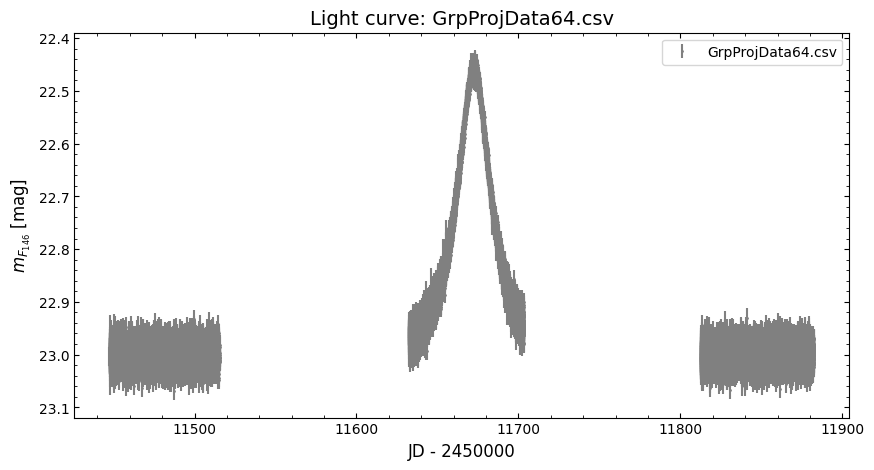

In [8]:
# Load the data using pandas
path = pointlensdata_path
filename = f'GrpProjData64.csv'  # assigned file
data = pd.read_csv(os.path.join(path, filename))
display(data.head())

# Optional: look up truth/metadata for your file (for self-checking later)
summary_path = os.path.join(path, 'summary.csv')
if os.path.isfile(summary_path):
    summary = pd.read_csv(summary_path)
    meta = summary.loc[summary['data_file'] == filename]
    if len(meta):
        print('Metadata for this file:')
        display(meta.T)
        t_0_ref = float(meta['t_0'].iloc[0])  # convenient parallax reference near peak
        coords_ra = str(meta['ra'].iloc[0]).strip()
        coords_dec = str(meta['dec'].iloc[0]).strip()
    else:
        t_0_ref = None
        coords_ra, coords_dec = "17:52:41.16", "-29:16:46.29"
else:
    t_0_ref = None
    coords_ra, coords_dec = "17:52:41.16", "-29:16:46.29"

# Load into MulensModel
my_data = mm.MulensData(
    data_list=[data['time'].values, data['magF146'].values, data['magF146err'].values],
    phot_fmt='mag'
)

# Plot the light curve
plt.figure(figsize=(10, 5))
my_data.plot(
    subtract_2450000=True,
    color='gray',
    marker='.',
    linestyle='None',
    markersize=2,
    label=filename,
)
plt.legend()
plt.xlabel('JD - 2450000', fontsize=12)
plt.ylabel(r'$m_{F_{146}}$ [mag]', fontsize=12)
plt.title(f'Light curve: {filename}', fontsize=14)
plt.show()


## Section 2 — Rough estimate of initial parameters

In [9]:
# Estimate initial parameters t_0, u_0, t_E from the light curve
# t_0 is approximately the time of minimum magnitude (peak brightness)
imin = np.argmin(data['magF146'].values)
t_0_guess = float(data['time'].values[imin])

# u_0 is typically between 0 and 1; start mid-range and let the fit refine it
u_0_guess = 0.5

# t_E is roughly the duration of the magnified event
mag = data['magF146'].values
t = data['time'].values
baseline = np.median(mag)
peak_mag = mag[imin]
half_level = 0.5 * (baseline + peak_mag)
bright = mag < half_level
if bright.any():
    t_E_guess = float(max(1.0, 0.5 * (t[bright].max() - t[bright].min())))
else:
    t_E_guess = 20.0

# Parallax reference time: use metadata peak if available, else our guess
if t_0_ref is None:
    t_0_ref = t_0_guess

print(f"Estimated t_0: {t_0_guess:.2f}, t_E: {t_E_guess:.2f}, u_0: {u_0_guess:.2f}")
print(f"Using t_0_ref = {t_0_ref:.2f}, coords = {coords_ra} {coords_dec}")


Estimated t_0: 2461672.96, t_E: 12.03, u_0: 0.50
Using t_0_ref = 2461672.60, coords = 17:52:41.16 -29:16:46.29


## Key idea in light curve fitting: Minimization vs. MCMC
Microlensing light curve fitting involves evaluating the likelihood space, which can be highly degenerate and complex. To solve these models efficiently, we can follow a strict 2-step workflow:

1. **Minimizer First:** We use an optimizer (like `iminuit` or `scipy.optimize`) first to rapidly descend into the global minimum of our $\chi^2$ surface. This gives us the absolute "best-fit" approximate parameters, but minimizers are poor at estimating the *errors* (uncertainties) of these parameters.
2. **MCMC Second:** Markov Chain Monte Carlo (MCMC) is a *sampler*, not an optimizer. Its job is to map out the posterior distribution (error bars and correlations). If you start MCMC walkers randomly, they will spend immense amounts of computational time wandering around looking for the minimum. By initializing walkers in a tight ball exactly *around* the minimizer's best-fit result, MCMC can immediately start exploring the local parameter space, yielding accurate uncertainties and beautiful corner plots.

## Section 3 — Fit a PSPL model (Minimizer)

In [10]:
# Set up the initial model and event (for plotting the guess later)
init_pspl_model = mm.Model({'t_0': t_0_guess, 'u_0': u_0_guess, 't_E': t_E_guess})
init_event_pspl = mm.Event(datasets=my_data, model=init_pspl_model)
init_event_pspl.fit_fluxes()  # Fit source and blend fluxes to the data

# Set up the model and event that we will actually minimize
pspl_model = mm.Model({'t_0': t_0_guess, 'u_0': u_0_guess, 't_E': t_E_guess})
event_pspl = mm.Event(datasets=my_data, model=pspl_model)
event_pspl.fit_fluxes()  # Fit source and blend fluxes to the data

pspl_params = ['t_0', 'u_0', 't_E']

# Bounds for the minimizer: t_0/u_0 unbounded; t_E strictly positive
bounds_pspl = [(None, None), (None, None), (1e-6, None)]

# Minimize chi2 to find best-fit parameters using iminuit
m_pspl = minimize(
    chi2_fun,
    x0=[t_0_guess, u_0_guess, t_E_guess],
    args=(pspl_params, event_pspl),
    bounds=bounds_pspl,
)
best_pspl = m_pspl.x

# Update event to best-fit and extract fs
for p, v in zip(pspl_params, best_pspl):
    setattr(event_pspl.model.parameters, p, v)
event_pspl.fit_fluxes()
fs = float(
    event_pspl.source_fluxes[0]
    / (event_pspl.source_fluxes[0] + event_pspl.blend_fluxes[0])
)

# Degrees of freedom and minimum chi2
n_epochs = len(event_pspl.datasets[0].time)
dof_pspl = n_epochs - len(pspl_params)
chi2min_pspl = chi2_fun(best_pspl, pspl_params, event_pspl)

# z-score for large dof: z = (chi2 - dof) / sqrt(2 * dof)
z_score_pspl = (chi2min_pspl - dof_pspl) / np.sqrt(2 * dof_pspl)

print('iminuit success:', m_pspl.success, m_pspl.message)
print('Best PSPL:', dict(zip(pspl_params, best_pspl)))
print(
    f'fs={fs:.4f}, chi2={chi2min_pspl:.2f}, dof={dof_pspl}, '
    f'chi2/dof={chi2min_pspl/dof_pspl:.3f}, z={z_score_pspl:.2f}'
)


iminuit success: True Optimization terminated successfully.
Best PSPL: {'t_0': np.float64(2461672.4998473283), 'u_0': np.float64(0.4539272201275851), 't_E': np.float64(20.068292803479853)}
fs=0.4735, chi2=25260.17, dof=24871, chi2/dof=1.016, z=1.74


/tmp/ipykernel_4617/3487875433.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fs = float(


<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_4617/3103144639.py:20: SyntaxWarning: invalid escape sequence '\c'
  + f'\n\n$\chi^2_{{min}}$: {chi2min_pspl:.2f}\nDOF: {dof_pspl}\n'
/tmp/ipykernel_4617/3103144639.py:21: SyntaxWarning: invalid escape sequence '\c'
  + f'$\chi^2_{{min}}$/DOF: {chi2min_pspl/dof_pspl:.3f}'


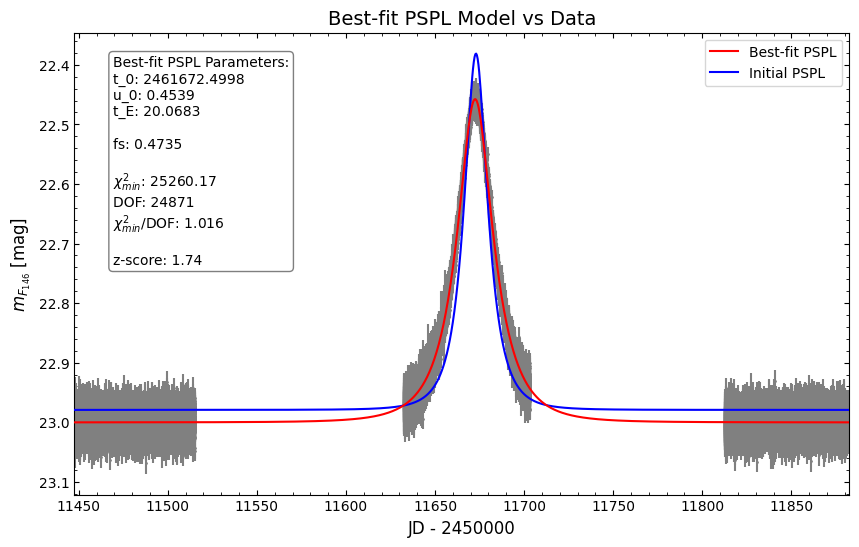

In [11]:
# Plot the initial model, best-fit model, and data
t_range = (data['time'].min(), data['time'].max())
plt.figure(figsize=(10, 6))
event_pspl.plot_model(
    t_range=t_range, color='red', subtract_2450000=True, zorder=4, label='Best-fit PSPL'
)
init_event_pspl.plot_model(
    t_range=t_range, color='blue', subtract_2450000=True, zorder=3, label='Initial PSPL'
)
init_event_pspl.plot_data(
    subtract_2450000=True, color='gray', marker='.', linestyle='None', markersize=2
)

plt.text(
    0.05,
    0.95,
    'Best-fit PSPL Parameters:\n'
    + '\n'.join([f'{param}: {val:.4f}' for param, val in zip(pspl_params, best_pspl)])
    + f'\n\nfs: {fs:.4f}'
    + f'\n\n$\chi^2_{{min}}$: {chi2min_pspl:.2f}\nDOF: {dof_pspl}\n'
    + f'$\chi^2_{{min}}$/DOF: {chi2min_pspl/dof_pspl:.3f}'
    + f'\n\nz-score: {z_score_pspl:.2f}',
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
)

plt.legend()
plt.xlabel('JD - 2450000', fontsize=12)
plt.ylabel(r'$m_{F_{146}}$ [mag]', fontsize=12)
plt.title('Best-fit PSPL Model vs Data', fontsize=14)
plt.show()


## Section 4 — MCMC run for PSPL

In [12]:
n_dim = len(pspl_params)

# MCMC hyperparameters
n_walkers = 3 * n_dim  # 2-4x n_dim
n_steps = 2000         # 1000-3000
n_burn = 300           # 100-500
thin = 1

# Initialize walkers near the minimizer solution
pos = best_pspl + 1e-4 * np.random.randn(n_walkers, n_dim)

# Ensure t_E stays positive for all walkers
pos[:, pspl_params.index('t_E')] = np.abs(pos[:, pspl_params.index('t_E')])

# Reset best-tracker used inside ln_like
ln_like.best = [np.inf]

# Initialize / run MCMC
sampler_pspl = emcee.EnsembleSampler(
    n_walkers, n_dim, ln_prob, args=(event_pspl, pspl_params)
)
sampler_pspl.run_mcmc(pos, n_steps, progress=True)


100%|██████████| 2000/2000 [08:16<00:00,  4.03it/s]


State([[2.46167249e+06 4.54068599e-01 2.00793710e+01]
 [2.46167251e+06 4.54589554e-01 2.00344766e+01]
 [2.46167249e+06 4.47685652e-01 2.02303546e+01]
 [2.46167251e+06 4.60125935e-01 1.99023238e+01]
 [2.46167250e+06 4.60623537e-01 1.98825554e+01]
 [2.46167249e+06 4.63232264e-01 1.98530994e+01]
 [2.46167249e+06 4.60658545e-01 1.98403430e+01]
 [2.46167250e+06 4.56331618e-01 1.99674977e+01]
 [2.46167250e+06 4.43469999e-01 2.03799202e+01]], log_prob=[-12630.61973928 -12630.59029456 -12632.11174615 -12632.00592262
 -12630.83604893 -12634.30038455 -12632.47787931 -12631.16697102
 -12632.01684206], blobs=[0.47358444 0.47461379 0.46426973 0.4828249  0.4836365  0.48726968
 0.48403631 0.47739679 0.45780037], random_state=('MT19937', array([1617702900,   81282413,  360868249, 2795352036, 2131911355,
       3619627664, 2896439697, 1455956780, 3970044631, 1630616586,
       3489306117, 3149859901, 4115081576,  264457011,  529840381,
        891435725, 2316890756, 4132723231, 4148108822, 1257764585,


In [13]:
# Extract the chains and blobs (blobs contain our fs parameter calculated in ln_prob)
samples_pspl = np.concatenate(
    [sampler_pspl.get_chain(), sampler_pspl.get_blobs()[:, :, np.newaxis]], axis=2
)
flat_samples_pspl = np.concatenate(
    [
        sampler_pspl.get_chain(discard=n_burn, thin=thin, flat=True),
        sampler_pspl.get_blobs(discard=n_burn, thin=thin, flat=True)[:, np.newaxis],
    ],
    axis=1,
)

# Median and standard deviation (errors)
med_pspl = np.median(flat_samples_pspl, axis=0)
err_pspl = np.std(flat_samples_pspl, axis=0)

print('MCMC medians:', dict(zip(pspl_params + ['fs'], med_pspl)))
print('MCMC errors :', dict(zip(pspl_params + ['fs'], err_pspl)))


MCMC medians: {'t_0': np.float64(2461672.4995482056), 'u_0': np.float64(0.4538880721095145), 't_E': np.float64(20.06858606156729), 'fs': np.float64(0.4734493023015262)}
MCMC errors : {'t_0': np.float64(0.007744501097972968), 'u_0': np.float64(0.005403896357019913), 't_E': np.float64(0.1573381269075109), 'fs': np.float64(0.008174269854264522)}


<>:60: SyntaxWarning: invalid escape sequence '\c'
<>:61: SyntaxWarning: invalid escape sequence '\c'
<>:60: SyntaxWarning: invalid escape sequence '\c'
<>:61: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_4617/1850858417.py:60: SyntaxWarning: invalid escape sequence '\c'
  + f'\n\n$\chi^2$: {chi2_mcmc_pspl:.2f}\nDOF: {dof_pspl}\n'
/tmp/ipykernel_4617/1850858417.py:61: SyntaxWarning: invalid escape sequence '\c'
  + f'$\chi^2$/DOF: {chi2_mcmc_pspl/dof_pspl:.3f}'


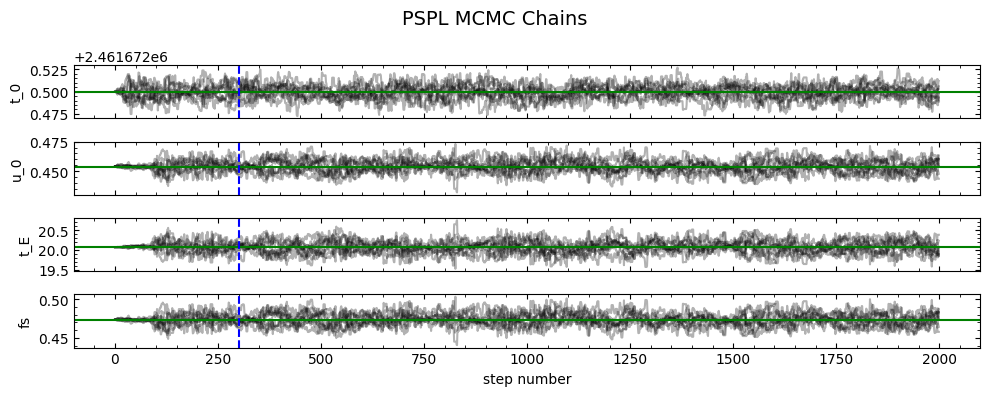

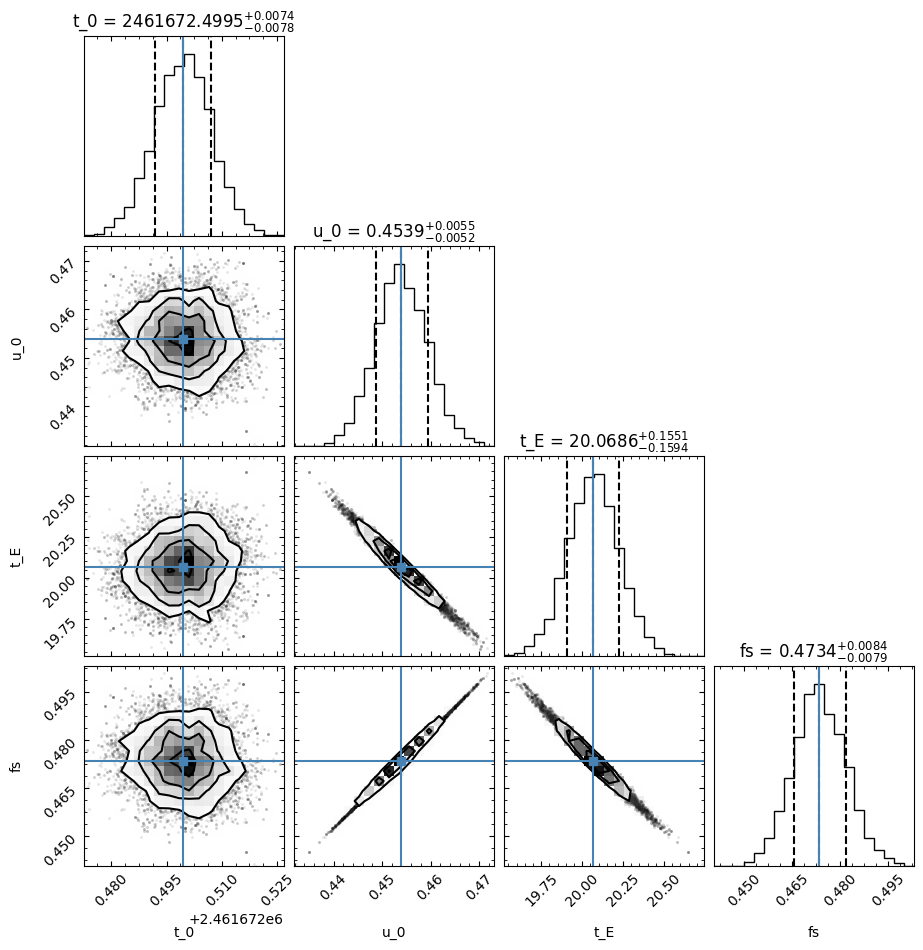

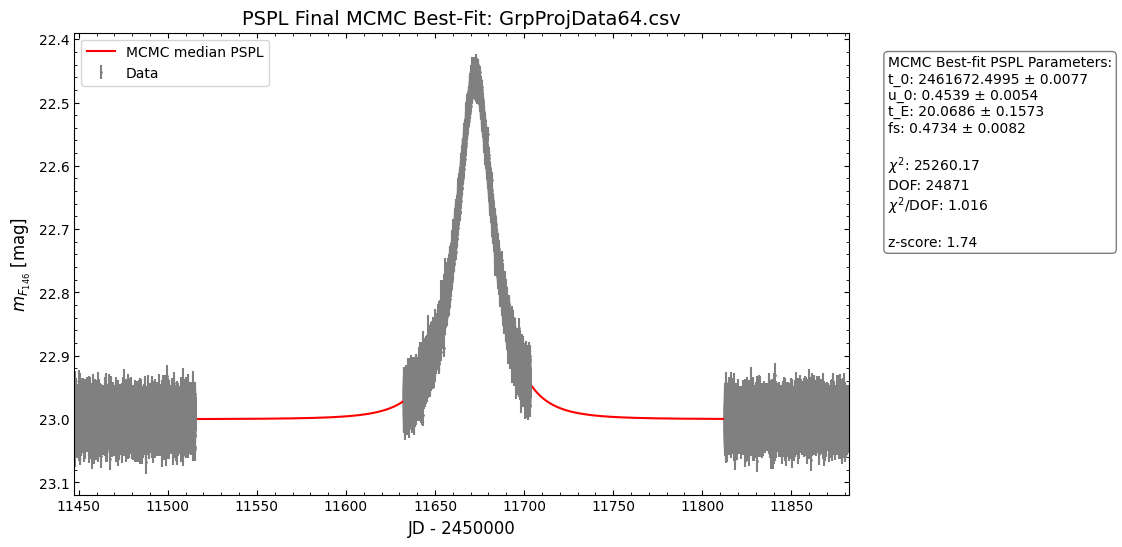

In [14]:
# Parameters including source flux fraction
pspl_params_with_fs = pspl_params + ['fs']
nrows = len(pspl_params_with_fs)

# MCMC chains
fig, axes = plt.subplots(nrows, 1, figsize=(10, 1 * nrows), sharex=True)
for i in range(nrows):
    axes[i].plot(samples_pspl[:, :, i], 'k', alpha=0.3)
    axes[i].axhline(med_pspl[i], color='green', linestyle='-')
    axes[i].axvline(n_burn, color='blue', linestyle='--')
    axes[i].set_ylabel(pspl_params_with_fs[i])
axes[-1].set_xlabel('step number')
fig.suptitle('PSPL MCMC Chains', fontsize=14)
plt.tight_layout()
plt.show()

# Corner plot
fig = corner.corner(
    flat_samples_pspl,
    labels=pspl_params_with_fs,
    truths=med_pspl,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt='.4f',
)
plt.show()

# chi2 / dof / z-score at MCMC median geometric parameters
chi2_mcmc_pspl = chi2_fun(med_pspl[: len(pspl_params)], pspl_params, event_pspl)
dof_pspl = len(event_pspl.datasets[0].time) - len(pspl_params)
z_score_mcmc_pspl = (chi2_mcmc_pspl - dof_pspl) / np.sqrt(2 * dof_pspl)

# Plot data + MCMC median model
plt.figure(figsize=(10, 6))
event_pspl.plot_data(
    subtract_2450000=True,
    color='gray',
    marker='.',
    linestyle='None',
    markersize=2,
    label='Data',
)
event_pspl.plot_model(
    t_range=(data['time'].min(), data['time'].max()),
    color='red',
    subtract_2450000=True,
    label='MCMC median PSPL',
)

plt.text(
    1.05,
    0.95,
    'MCMC Best-fit PSPL Parameters:\n'
    + '\n'.join(
        [
            f'{param}: {val:.4f} ± {e:.4f}'
            for param, val, e in zip(pspl_params_with_fs, med_pspl, err_pspl)
        ]
    )
    + f'\n\n$\chi^2$: {chi2_mcmc_pspl:.2f}\nDOF: {dof_pspl}\n'
    + f'$\chi^2$/DOF: {chi2_mcmc_pspl/dof_pspl:.3f}'
    + f'\n\nz-score: {z_score_mcmc_pspl:.2f}',
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
)

plt.legend(loc='upper left')
plt.xlabel('JD - 2450000', fontsize=12)
plt.ylabel(r'$m_{F_{146}}$ [mag]', fontsize=12)
plt.title(f'PSPL Final MCMC Best-Fit: {filename}', fontsize=14)
plt.show()


## Now, data binning is needed to explore Higher order effects faster
When fitting higher-order effects like Finite Source (FSPL) or Parallax, generating the model requires computationally intensive integration (e.g., over the stellar disk or the Earth's orbit).

To ensure the minimizer and MCMC converge quickly, we apply a **strategic data reduction/binning technique** via the `reduce_data_to_speedup` helper function:
1. **Inverse-Variance Weighting:** The `bin_lightcurve` function groups observations within a specific time window. It calculates the mean time, and computes a weighted average of the magnitudes using $1/\sigma^2$, yielding a single robust data point with properly propagated errors.
2. **Preserving the Peak for FS effect:** Finite source effects generally manifest strongly only near $t_0$. Therefore, regions far from $t_0$ are aggressively binned (e.g., 1-day bins) to save time, while the "peak" region is either left unbinned or lightly binned to preserve the shape necessary to accurately fit $\rho$.
3. **Keeping the peak season:** We can keep the peak season and chop off the other season while FS effect is explored. However, while exploring parallax Keep all the season for maximizing the parallax signal.

## Section 5 — Exploring Higher Order Effects

Choose **one** of the three models below by uncommenting it.
Make sure data is binned before running FSPL or parallax fits.

| Choice | Extra params | Difficulty-level |
|--------|-------------|------------------|
| **FSPL** | $\rho$ | Low |
| **PSPL+Parallax** | $\pi_{E,E}$, $\pi_{E,N}$ | Low |
| **FSPL+Parallax** | $\rho$, $\pi_{E,E}$, $\pi_{E,N}$ | High |

**TODO:** Uncomment your chosen model.

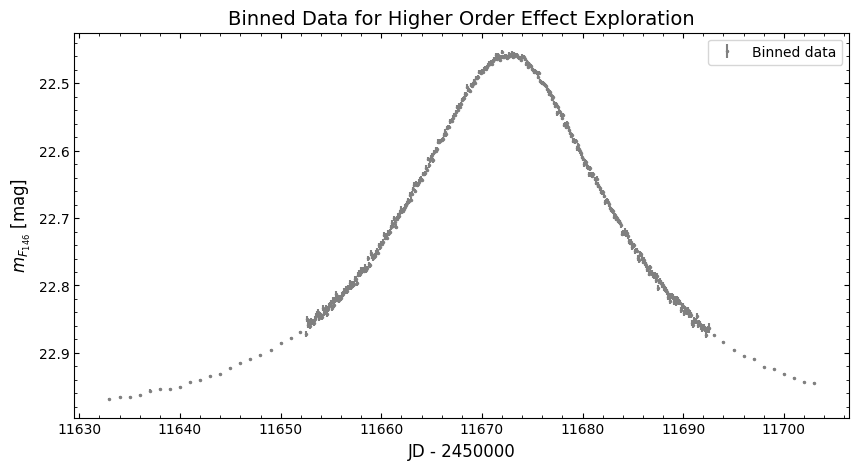

Original N=24874, binned N=433


In [15]:
# Extract best-fit PSPL parameters as initial guesses for higher-order models
t_0_guess, u_0_guess, t_E_guess = best_pspl

# Bin the data and limit the time range to speed up higher-order effect exploration
# For FSPL: keep peak seasons near t0. For parallax, prefer keeping more baseline/seasons.
binned_df = reduce_data_to_speedup(
    data,
    bin_width_days=1,
    t_range=(t_0_guess - 5 * t_E_guess, t_0_guess + 5 * t_E_guess),
    peak=(t_0_guess, t_E_guess, 0.1),
)

# Wrap the binned data into MulensData
binned_data = mm.MulensData(
    data_list=[
        binned_df['time'].values,
        binned_df['magF146'].values,
        binned_df['magF146err'].values,
    ],
    phot_fmt='mag',
)

# Visualize the binned data
plt.figure(figsize=(10, 5))
binned_data.plot(
    subtract_2450000=True,
    color='gray',
    marker='.',
    linestyle='None',
    markersize=3,
    label='Binned data',
)
plt.legend()
plt.ylabel(r'$m_{F_{146}}$ [mag]', fontsize=12)
plt.xlabel('JD - 2450000', fontsize=12)
plt.title('Binned Data for Higher Order Effect Exploration', fontsize=14)
plt.show()

print(f'Original N={len(data)}, binned N={len(binned_df)}')


<>:112: SyntaxWarning: invalid escape sequence '\c'
<>:113: SyntaxWarning: invalid escape sequence '\c'
<>:112: SyntaxWarning: invalid escape sequence '\c'
<>:113: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_4617/36201085.py:112: SyntaxWarning: invalid escape sequence '\c'
  + f'\n\n$\chi^2_{{min}}$: {chi2min_ho:.2f}\nDOF: {dof_ho}\n'
/tmp/ipykernel_4617/36201085.py:113: SyntaxWarning: invalid escape sequence '\c'
  + f'$\chi^2_{{min}}$/DOF: {chi2min_ho/dof_ho:.3f}'
/tmp/ipykernel_4617/36201085.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fs = float(


Higher-order minimizer success: False Optimization failed. Call limit was reached.
Best FSPL {'t_0': np.float64(2461672.5015614857), 'u_0': np.float64(0.48756840619239855), 't_E': np.float64(18.973460190346156), 'rho': np.float64(0.002346120158901581)}
fs=0.5224, chi2=656.41, dof=429, chi2/dof=1.530, z=7.76


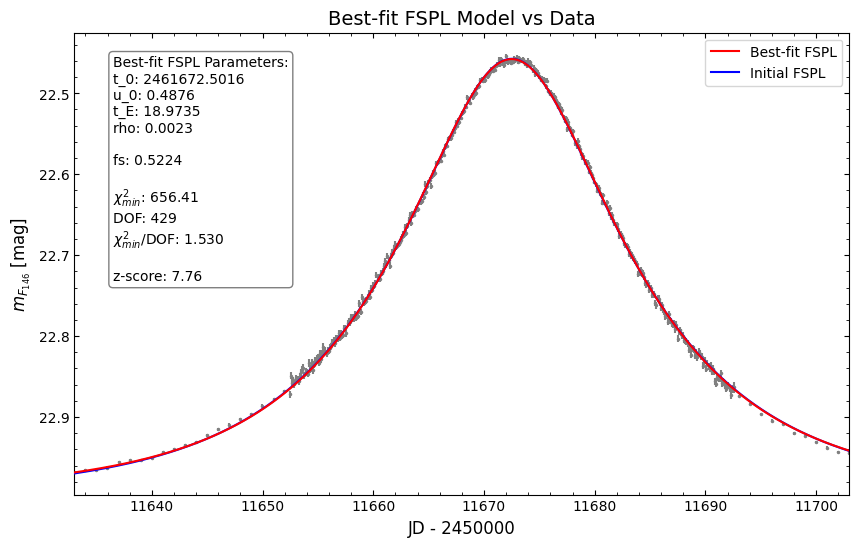

In [17]:
# Uncomment ONE higher-order option. Default completed choice: Option A (FSPL).

# Option A — FSPL  (default)
rho_guess = 0.05
FS_METHOD = finite_source_methods[1]
model_ho = mm.Model(
    {'t_0': t_0_guess, 'u_0': u_0_guess, 't_E': t_E_guess, 'rho': rho_guess}
)
model_ho.set_magnification_methods(
    [binned_df['time'].min(), FS_METHOD, binned_df['time'].max()]
)
model_label = 'FSPL'
labels_ho = ['t_0', 'u_0', 't_E', 'rho']

# Higher-order event + baseline fluxes
event_ho = mm.Event(datasets=binned_data, model=model_ho)
event_ho.fit_fluxes()

# Keep a copy of the initial model for comparison plotting
init_ho_model = mm.Model(
    {'t_0': t_0_guess, 'u_0': u_0_guess, 't_E': t_E_guess, 'rho': rho_guess}
)
init_ho_model.set_magnification_methods(
    [binned_df['time'].min(), FS_METHOD, binned_df['time'].max()]
)
init_event_ho = mm.Event(datasets=binned_data, model=init_ho_model)
init_event_ho.fit_fluxes()

# Parameters / bounds for chosen model (FSPL default)
ho_params = labels_ho
bounds_ho = [(None, None), (None, None), (1e-6, None), (1e-6, None)]
x0_ho = [t_0_guess, u_0_guess, t_E_guess, rho_guess]

# If using parallax options, replace bounds/x0 accordingly, e.g.:
# bounds_ho = [(None, None), (None, None), (1e-6, None), (None, None), (None, None)]
# x0_ho = [t_0_guess, u_0_guess, t_E_guess, pi_E_E_guess, pi_E_N_guess]

m_ho = minimize(
    chi2_fun, x0=x0_ho, args=(ho_params, event_ho), bounds=bounds_ho
)
best_ho = m_ho.x

for p, v in zip(ho_params, best_ho):
    setattr(event_ho.model.parameters, p, v)
event_ho.fit_fluxes()

fs = float(
    event_ho.source_fluxes[0] / (event_ho.source_fluxes[0] + event_ho.blend_fluxes[0])
)
dof_ho = len(event_ho.datasets[0].time) - len(ho_params)
chi2min_ho = chi2_fun(best_ho, ho_params, event_ho)
z_score_ho = (chi2min_ho - dof_ho) / np.sqrt(2 * dof_ho)

print('Higher-order minimizer success:', m_ho.success, m_ho.message)
print('Best', model_label, dict(zip(ho_params, best_ho)))
print(
    f'fs={fs:.4f}, chi2={chi2min_ho:.2f}, dof={dof_ho}, '
    f'chi2/dof={chi2min_ho/dof_ho:.3f}, z={z_score_ho:.2f}'
)

# Plot
plt.figure(figsize=(10, 6))
t_range_ho = (binned_df['time'].min(), binned_df['time'].max())
event_ho.plot_model(
    t_range=t_range_ho,
    color='red',
    subtract_2450000=True,
    zorder=4,
    label=f'Best-fit {model_label}',
)
init_event_ho.plot_model(
    t_range=t_range_ho,
    color='blue',
    subtract_2450000=True,
    zorder=3,
    label=f'Initial {model_label}',
)
init_event_ho.plot_data(
    subtract_2450000=True, color='gray', marker='.', linestyle='None', markersize=3
)

plt.text(
    0.05,
    0.95,
    f'Best-fit {model_label} Parameters:\n'
    + '\n'.join([f'{param}: {val:.4f}' for param, val in zip(ho_params, best_ho)])
    + f'\n\nfs: {fs:.4f}'
    + f'\n\n$\chi^2_{{min}}$: {chi2min_ho:.2f}\nDOF: {dof_ho}\n'
    + f'$\chi^2_{{min}}$/DOF: {chi2min_ho/dof_ho:.3f}'
    + f'\n\nz-score: {z_score_ho:.2f}',
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
)

plt.legend()
plt.xlabel('JD - 2450000', fontsize=12)
plt.ylabel(r'$m_{F_{146}}$ [mag]', fontsize=12)
plt.title(f'Best-fit {model_label} Model vs Data', fontsize=14)
plt.show()


/tmp/ipykernel_4617/2994780843.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fs = float(


Higher-order minimizer success: False Optimization failed. Call limit was reached.
Best FSPL+Parallax {'t_0': np.float64(2461672.605721222), 'u_0': np.float64(0.45384822613387926), 't_E': np.float64(20.174633607448076), 'rho': np.float64(0.11621375899718872), 'pi_E_E': np.float64(0.3338693524720791), 'pi_E_N': np.float64(-0.13762644572600308)}
fs=0.4683, chi2=402.29, dof=427, chi2/dof=0.942, z=-0.85


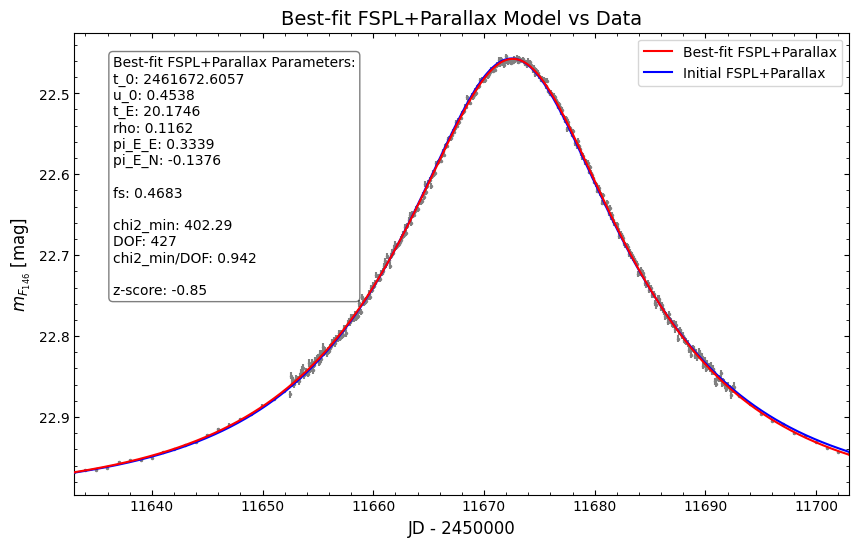

In [23]:
# IMPORTANT MulensModel rules:
# 1) Put t_0_par INSIDE the Model(...) parameter dictionary (not in .parallax()).
# 2) Call model.parallax(earth_orbital=True) with NO t_0_ref keyword.
# 3) Workshop notes say t_0_ref; MulensModel's actual name is t_0_par.

# Fixed parallax reference epoch (do NOT fit this)
t_0_par = float(t_0_ref)
coords = f"{coords_ra} {coords_dec}"

# ── Option C — FSPL + Parallax (ACTIVE) ─────────────────────────────────────
rho_guess = 0.05
FS_METHOD = finite_source_methods[1]
pi_E_E_guess, pi_E_N_guess = 0.1, 0.1
model_ho = mm.Model(
    {
        't_0': t_0_guess,
        'u_0': u_0_guess,
        't_E': t_E_guess,
        'rho': rho_guess,
        'pi_E_E': pi_E_E_guess,
        'pi_E_N': pi_E_N_guess,
        't_0_par': t_0_par,   # fixed reference epoch for parallax
    },
    coords=coords,
)
model_ho.set_magnification_methods(
    [binned_df['time'].min(), FS_METHOD, binned_df['time'].max()]
)
model_ho.parallax(earth_orbital=True)  # NO t_0_ref / t_0_par here
model_label = 'FSPL+Parallax'
labels_ho = ['t_0', 'u_0', 't_E', 'rho', 'pi_E_E', 'pi_E_N']
bounds_ho = [
    (None, None), (None, None), (1e-6, None), (1e-6, None), (None, None), (None, None)
]
x0_ho = [t_0_guess, u_0_guess, t_E_guess, rho_guess, pi_E_E_guess, pi_E_N_guess]
init_params = {
    't_0': t_0_guess,
    'u_0': u_0_guess,
    't_E': t_E_guess,
    'rho': rho_guess,
    'pi_E_E': pi_E_E_guess,
    'pi_E_N': pi_E_N_guess,
    't_0_par': t_0_par,
}
init_coords = coords
use_fs_methods = True
use_parallax = True

# ── Build events ────────────────────────────────────────────────────────────
event_ho = mm.Event(datasets=binned_data, model=model_ho)
event_ho.fit_fluxes()

init_ho_model = mm.Model(init_params, coords=init_coords)
if use_fs_methods:
    init_ho_model.set_magnification_methods(
        [binned_df['time'].min(), FS_METHOD, binned_df['time'].max()]
    )
if use_parallax:
    init_ho_model.parallax(earth_orbital=True)
init_event_ho = mm.Event(datasets=binned_data, model=init_ho_model)
init_event_ho.fit_fluxes()

ho_params = labels_ho
m_ho = minimize(chi2_fun, x0=x0_ho, args=(ho_params, event_ho), bounds=bounds_ho)
best_ho = m_ho.x

for p, v in zip(ho_params, best_ho):
    setattr(event_ho.model.parameters, p, v)
event_ho.fit_fluxes()

fs = float(
    event_ho.source_fluxes[0] / (event_ho.source_fluxes[0] + event_ho.blend_fluxes[0])
)
dof_ho = len(event_ho.datasets[0].time) - len(ho_params)
chi2min_ho = chi2_fun(best_ho, ho_params, event_ho)
z_score_ho = (chi2min_ho - dof_ho) / np.sqrt(2 * dof_ho)

print('Higher-order minimizer success:', m_ho.success, m_ho.message)
print('Best', model_label, dict(zip(ho_params, best_ho)))
print(
    f'fs={fs:.4f}, chi2={chi2min_ho:.2f}, dof={dof_ho}, '
    f'chi2/dof={chi2min_ho/dof_ho:.3f}, z={z_score_ho:.2f}'
)

# Plot
plt.figure(figsize=(10, 6))
t_range_ho = (binned_df['time'].min(), binned_df['time'].max())
event_ho.plot_model(
    t_range=t_range_ho,
    color='red',
    subtract_2450000=True,
    zorder=4,
    label=f'Best-fit {model_label}',
)
init_event_ho.plot_model(
    t_range=t_range_ho,
    color='blue',
    subtract_2450000=True,
    zorder=3,
    label=f'Initial {model_label}',
)
init_event_ho.plot_data(
    subtract_2450000=True, color='gray', marker='.', linestyle='None', markersize=3
)

param_lines = '\n'.join(f'{param}: {val:.4f}' for param, val in zip(ho_params, best_ho))
stats_text = (
    f'Best-fit {model_label} Parameters:\n'
    f'{param_lines}\n\n'
    f'fs: {fs:.4f}\n\n'
    f'chi2_min: {chi2min_ho:.2f}\n'
    f'DOF: {dof_ho}\n'
    f'chi2_min/DOF: {chi2min_ho/dof_ho:.3f}\n\n'
    f'z-score: {z_score_ho:.2f}'
)
plt.text(
    0.05,
    0.95,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
)

plt.legend()
plt.xlabel('JD - 2450000', fontsize=12)
plt.ylabel(r'$m_{F_{146}}$ [mag]', fontsize=12)
plt.title(f'Best-fit {model_label} Model vs Data', fontsize=14)
plt.show()


<>:101: SyntaxWarning: invalid escape sequence '\c'
<>:102: SyntaxWarning: invalid escape sequence '\c'
<>:101: SyntaxWarning: invalid escape sequence '\c'
<>:102: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_4617/899048339.py:101: SyntaxWarning: invalid escape sequence '\c'
  + f'\n\n$\chi^2_{{min}}$: {chi2min_ho:.2f}\nDOF: {dof_ho}\n'
/tmp/ipykernel_4617/899048339.py:102: SyntaxWarning: invalid escape sequence '\c'
  + f'$\chi^2_{{min}}$/DOF: {chi2min_ho/dof_ho:.3f}'
/tmp/ipykernel_4617/899048339.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fs = float(


Higher-order minimizer success: True Optimization terminated successfully.
Best PSPL+Parallax {'t_0': np.float64(2461672.6057924815), 'u_0': np.float64(0.4476863824495339), 't_E': np.float64(20.395312003063435), 'pi_E_E': np.float64(0.33789355369983154)}
fs=0.4658, chi2=402.26, dof=428, chi2/dof=0.940, z=-0.88


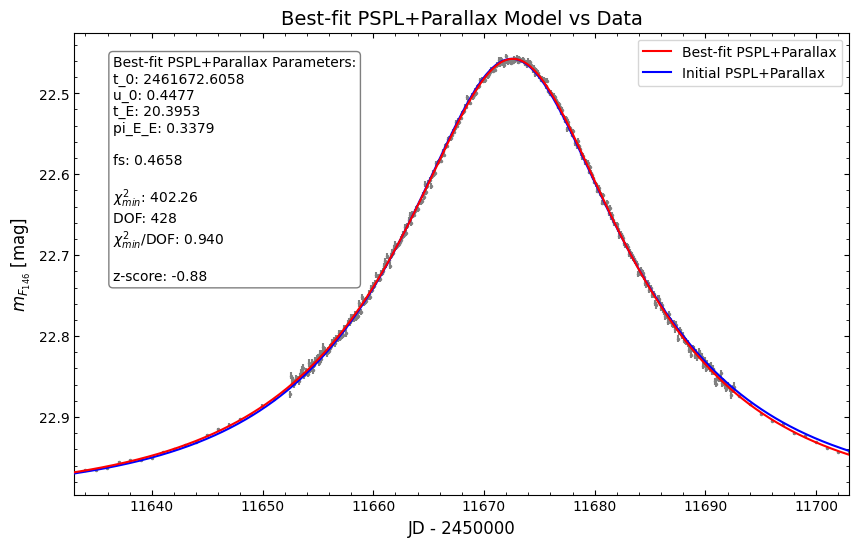

In [24]:
t_0_par = float(t_0_ref)
coords = f"{coords_ra} {coords_dec}"

## ── Option B — PSPL + Parallax ──────────────────────────────────────────────
pi_E_E_guess, pi_E_N_guess = 0.1, 0.1
model_ho = mm.Model(
    {
        't_0': t_0_guess, 'u_0': u_0_guess, 't_E': t_E_guess,
        'pi_E_E': pi_E_E_guess, 'pi_E_N': pi_E_N_guess,
        't_0_par': t_0_par,
    },
    coords=coords,
)
model_ho.parallax(earth_orbital=True)
model_label = 'PSPL+Parallax'
labels_ho = ['t_0', 'u_0', 't_E', 'pi_E_E', 'pi_E_N']
bounds_ho = [(None, None), (None, None), (1e-6, None), (None, None), (None, None)]
x0_ho = [t_0_guess, u_0_guess, t_E_guess, pi_E_E_guess, pi_E_N_guess]
init_params = {
    't_0': t_0_guess, 'u_0': u_0_guess, 't_E': t_E_guess,
    'pi_E_E': pi_E_E_guess, 'pi_E_N': pi_E_N_guess, 't_0_par': t_0_par,
}
init_coords = coords
use_fs_methods = False
use_parallax = True


# Higher-order event + baseline fluxes
event_ho = mm.Event(datasets=binned_data, model=model_ho)
event_ho.fit_fluxes()

# Keep a copy of the initial model for comparison plotting
init_ho_model = mm.Model(
    {'t_0': t_0_guess, 'u_0': u_0_guess, 't_E': t_E_guess, 'rho': rho_guess}
)
init_ho_model.set_magnification_methods(
    [binned_df['time'].min(), FS_METHOD, binned_df['time'].max()]
)
init_event_ho = mm.Event(datasets=binned_data, model=init_ho_model)
init_event_ho.fit_fluxes()

# Parameters / bounds for chosen model (FSPL default)
ho_params = labels_ho
bounds_ho = [(None, None), (None, None), (1e-6, None), (1e-6, None)]
x0_ho = [t_0_guess, u_0_guess, t_E_guess, rho_guess]

# If using parallax options, replace bounds/x0 accordingly, e.g.:
# bounds_ho = [(None, None), (None, None), (1e-6, None), (None, None), (None, None)]
# x0_ho = [t_0_guess, u_0_guess, t_E_guess, pi_E_E_guess, pi_E_N_guess]

m_ho = minimize(
    chi2_fun, x0=x0_ho, args=(ho_params, event_ho), bounds=bounds_ho
)
best_ho = m_ho.x

for p, v in zip(ho_params, best_ho):
    setattr(event_ho.model.parameters, p, v)
event_ho.fit_fluxes()

fs = float(
    event_ho.source_fluxes[0] / (event_ho.source_fluxes[0] + event_ho.blend_fluxes[0])
)
dof_ho = len(event_ho.datasets[0].time) - len(ho_params)
chi2min_ho = chi2_fun(best_ho, ho_params, event_ho)
z_score_ho = (chi2min_ho - dof_ho) / np.sqrt(2 * dof_ho)

print('Higher-order minimizer success:', m_ho.success, m_ho.message)
print('Best', model_label, dict(zip(ho_params, best_ho)))
print(
    f'fs={fs:.4f}, chi2={chi2min_ho:.2f}, dof={dof_ho}, '
    f'chi2/dof={chi2min_ho/dof_ho:.3f}, z={z_score_ho:.2f}'
)

# Plot
plt.figure(figsize=(10, 6))
t_range_ho = (binned_df['time'].min(), binned_df['time'].max())
event_ho.plot_model(
    t_range=t_range_ho,
    color='red',
    subtract_2450000=True,
    zorder=4,
    label=f'Best-fit {model_label}',
)
init_event_ho.plot_model(
    t_range=t_range_ho,
    color='blue',
    subtract_2450000=True,
    zorder=3,
    label=f'Initial {model_label}',
)
init_event_ho.plot_data(
    subtract_2450000=True, color='gray', marker='.', linestyle='None', markersize=3
)

plt.text(
    0.05,
    0.95,
    f'Best-fit {model_label} Parameters:\n'
    + '\n'.join([f'{param}: {val:.4f}' for param, val in zip(ho_params, best_ho)])
    + f'\n\nfs: {fs:.4f}'
    + f'\n\n$\chi^2_{{min}}$: {chi2min_ho:.2f}\nDOF: {dof_ho}\n'
    + f'$\chi^2_{{min}}$/DOF: {chi2min_ho/dof_ho:.3f}'
    + f'\n\nz-score: {z_score_ho:.2f}',
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
)

plt.legend()
plt.xlabel('JD - 2450000', fontsize=12)
plt.ylabel(r'$m_{F_{146}}$ [mag]', fontsize=12)
plt.title(f'Best-fit {model_label} Model vs Data', fontsize=14)
plt.show()


## Section 6 — Compare Models

In [25]:
# Compare higher-order model vs PSPL using z-score
print(
    f'PSPL     : chi2={chi2min_pspl:.2f}, dof={dof_pspl}, '
    f'chi2/dof={chi2min_pspl/dof_pspl:.3f}, z={z_score_pspl:.2f}'
)
print(
    f'{model_label:8s} : chi2={chi2min_ho:.2f}, dof={dof_ho}, '
    f'chi2/dof={chi2min_ho/dof_ho:.3f}, z={z_score_ho:.2f}'
)

if z_score_ho < z_score_pspl:
    print(
        'Higher-order effect model is preferred over PSPL model based on '
        f'z-score comparison: {z_score_ho:.2f} < {z_score_pspl:.2f}'
    )
else:
    print(
        'PSPL is preferred (or comparable) based on z-score comparison: '
        f'{z_score_pspl:.2f} <= {z_score_ho:.2f}'
    )


PSPL     : chi2=25260.17, dof=24871, chi2/dof=1.016, z=1.74
PSPL+Parallax : chi2=402.26, dof=428, chi2/dof=0.940, z=-0.88
Higher-order effect model is preferred over PSPL model based on z-score comparison: -0.88 < 1.74


## Section 7 — OPTIONAL: Run MCMC for Higher Order Model

In [31]:
# OPTIONAL MCMC for higher-order model
# This cell auto-syncs labels to whatever best_ho currently contains,
# so you don't crash if Section 5 was re-run with a different option.

best_ho = np.asarray(best_ho, dtype=float).ravel()
n_dim = len(best_ho)

# Map fitted vector length -> parameter names
PARAM_MAP = {
    4: ['t_0', 'u_0', 't_E', 'rho'],                         # FSPL
    5: ['t_0', 'u_0', 't_E', 'pi_E_E', 'pi_E_N'],             # PSPL+Parallax
    6: ['t_0', 'u_0', 't_E', 'rho', 'pi_E_E', 'pi_E_N'],      # FSPL+Parallax
}
LABEL_MAP = {
    4: 'FSPL',
    5: 'PSPL+Parallax',
    6: 'FSPL+Parallax',
}

if n_dim not in PARAM_MAP:
    raise ValueError(
        f'Unexpected len(best_ho)={n_dim}. Expected 4, 5, or 6. '
        'Re-run the Section 5 minimizer cell first.'
    )

ho_params = PARAM_MAP[n_dim]
model_label = LABEL_MAP[n_dim]

print('Auto-synced MCMC setup from best_ho:')
print('  model_label =', model_label)
print('  ho_params   =', ho_params)
print('  best_ho     =', best_ho)

# Rebuild a matching model/event from best_ho so MCMC uses the same physics
t_0_par = float(t_0_ref)
coords = f"{coords_ra} {coords_dec}"
param_dict = dict(zip(ho_params, best_ho))

if n_dim in (5, 6):
    param_dict['t_0_par'] = t_0_par
    model_ho = mm.Model(param_dict, coords=coords)
    model_ho.parallax(earth_orbital=True)
else:
    model_ho = mm.Model(param_dict)

if 'rho' in ho_params:
    FS_METHOD = finite_source_methods[1]
    model_ho.set_magnification_methods(
        [binned_df['time'].min(), FS_METHOD, binned_df['time'].max()]
    )

event_ho = mm.Event(datasets=binned_data, model=model_ho)
for p, v in zip(ho_params, best_ho):
    setattr(event_ho.model.parameters, p, v)
event_ho.fit_fluxes()

n_walkers = 4 * n_dim
n_steps = 100
n_burn = 200
thin = 1

rng = np.random.default_rng()
pos = best_ho + 1e-4 * rng.normal(size=(n_walkers, n_dim))
if 't_E' in ho_params:
    pos[:, ho_params.index('t_E')] = np.abs(pos[:, ho_params.index('t_E')])
if 'rho' in ho_params:
    pos[:, ho_params.index('rho')] = np.abs(pos[:, ho_params.index('rho')])

print('  n_dim, n_walkers, n_steps =', n_dim, n_walkers, n_steps)

ln_like.best = [np.inf]
sampler_ho = emcee.EnsembleSampler(
    n_walkers, n_dim, ln_prob, args=(event_ho, ho_params)
)
sampler_ho.run_mcmc(pos, n_steps, progress=True)

samples_ho = np.concatenate(
    [sampler_ho.get_chain(), sampler_ho.get_blobs()[:, :, np.newaxis]], axis=2
)
flat_samples_ho = np.concatenate(
    [
        sampler_ho.get_chain(discard=n_burn, thin=thin, flat=True),
        sampler_ho.get_blobs(discard=n_burn, thin=thin, flat=True)[:, np.newaxis],
    ],
    axis=1,
)

med_ho = np.median(flat_samples_ho, axis=0)
err_ho = np.std(flat_samples_ho, axis=0)
print('HO MCMC medians:', dict(zip(ho_params + ['fs'], med_ho)))


Auto-synced MCMC setup from best_ho:
  model_label = FSPL
  ho_params   = ['t_0', 'u_0', 't_E', 'rho']
  best_ho     = [2.46167261e+06 4.47686382e-01 2.03953120e+01 3.37893554e-01]
  n_dim, n_walkers, n_steps = 4 16 100


100%|██████████| 100/100 [06:12<00:00,  3.73s/it]

HO MCMC medians: {'t_0': np.float64(nan), 'u_0': np.float64(nan), 't_E': np.float64(nan), 'rho': np.float64(nan), 'fs': np.float64(nan)}



/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:207: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


<>:55: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
<>:55: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_4617/3154257006.py:55: SyntaxWarning: invalid escape sequence '\c'
  + f'\n\n$\chi^2$: {chi2_mcmc_ho:.2f}\nDOF: {dof_ho}\n'
/tmp/ipykernel_4617/3154257006.py:56: SyntaxWarning: invalid escape sequence '\c'
  + f'$\chi^2$/DOF: {chi2_mcmc_ho/dof_ho:.3f}'


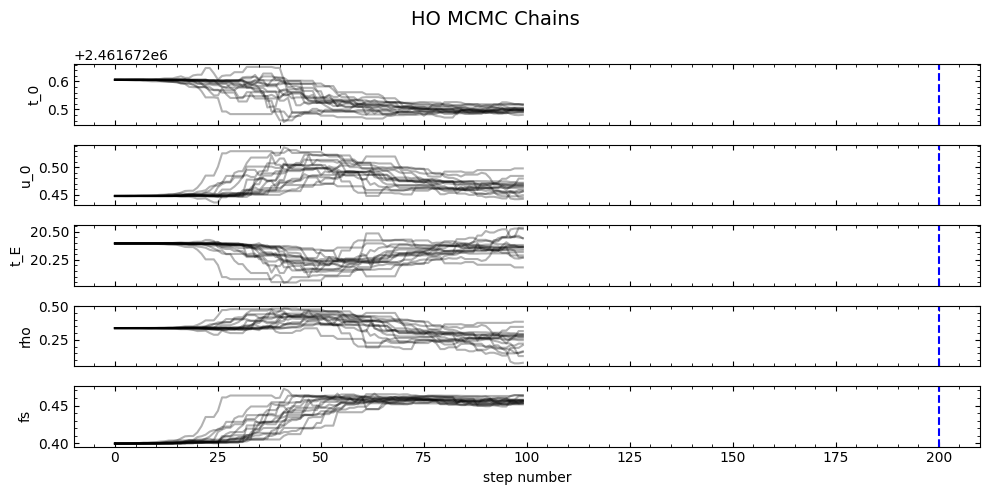

/usr/local/lib/python3.12/dist-packages/arviz/data/base.py:272: UserWarning: More chains (1) than draws (0). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


AssertionError: I don't believe that you want more dimensions than samples!

In [32]:
ho_params_with_fs = ho_params + ['fs']
nrows = len(ho_params_with_fs)

fig, axes = plt.subplots(nrows, 1, figsize=(10, 1 * nrows), sharex=True)
for i in range(nrows):
    axes[i].plot(samples_ho[:, :, i], 'k', alpha=0.3)
    axes[i].axhline(med_ho[i], color='green', linestyle='-')
    axes[i].axvline(n_burn, color='blue', linestyle='--')
    axes[i].set_ylabel(ho_params_with_fs[i])
axes[-1].set_xlabel('step number')
fig.suptitle('HO MCMC Chains', fontsize=14)
plt.tight_layout()
plt.show()

fig = corner.corner(
    flat_samples_ho,
    labels=ho_params_with_fs,
    truths=med_ho,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt='.4f',
)
plt.show()

chi2_mcmc_ho = chi2_fun(med_ho[: len(ho_params)], ho_params, event_ho)
dof_ho = len(event_ho.datasets[0].time) - len(ho_params)
z_score_mcmc_ho = (chi2_mcmc_ho - dof_ho) / np.sqrt(2 * dof_ho)

plt.figure(figsize=(10, 6))
event_ho.plot_data(
    subtract_2450000=True,
    color='gray',
    marker='.',
    linestyle='None',
    markersize=3,
    label='Binned data',
)
event_ho.plot_model(
    t_range=(binned_df['time'].min(), binned_df['time'].max()),
    color='red',
    subtract_2450000=True,
    label=f'MCMC median {model_label}',
)

plt.text(
    1.05,
    0.95,
    f'MCMC Best-fit {model_label} Parameters:\n'
    + '\n'.join(
        [
            f'{param}: {val:.4f} ± {e:.4f}'
            for param, val, e in zip(ho_params_with_fs, med_ho, err_ho)
        ]
    )
    + f'\n\n$\chi^2$: {chi2_mcmc_ho:.2f}\nDOF: {dof_ho}\n'
    + f'$\chi^2$/DOF: {chi2_mcmc_ho/dof_ho:.3f}'
    + f'\n\nz-score: {z_score_mcmc_ho:.2f}',
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
)

plt.legend(loc='upper left')
plt.xlabel('JD - 2450000', fontsize=12)
plt.ylabel(r'$m_{F_{146}}$ [mag]', fontsize=12)
plt.title(f'{model_label} Final MCMC Best-Fit: {filename}', fontsize=14)
plt.show()


---
# ======================= END =======